In [93]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [94]:
def inches(meters):
    return 1/0.0254 * meters

def meters(inches):
    return 0.0254 * inches
def weight(density, length, diameter, thickness):
    return 9.81 * density * length * np.pi * diameter * thickness

def buoyancy(density, length, diameter, thickness):
    return 9.81 * density *np.pi/4 * (diameter * thickness)**2 * length

In [95]:
# Read file
file_path = "Data.xlsx"
df = pd.read_excel(file_path)

# Read nodes
node_df = df[df["Nodes"].notna()]
nodes = {
    int(row["Nodes"]): (row["X"], row["Y"])
    for _, row in node_df.iterrows()}

# Make elements
elem_df = df[df["Members"].notna()].copy()
elements = []
leg_slope = 1/10 

for _, row in elem_df.iterrows():
    elem_id = int(row["Members"])
    elem_type = row["Type of elem"]
    n1, n2 = map(int, str(row["Nodes connected"]).split("-"))

    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    if elem_type == "H":
        Lh = abs(x2 - x1)

    elif elem_type == "K":
        L2Dk = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        L3Dk = L2Dk * np.sqrt(1 + leg_slope**2)

    elif elem_type == "Leg":
        L2DL = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        LEDL = L2DL * np.sqrt(1 + leg_slope**2)

    else:
        raise ValueError(f"Unknown element type: {elem_type}")

    elements.append({
        "id": elem_id,
        "type": elem_type,
        "nodes": (n1, n2),
        "Length": round(Lh if elem_type == "H" else L3Dk if elem_type == "K" else LEDL, 3)})

print("Number of elements:", len(elements))
for elem in elements:
    print(f'id: {elem["id"]} | type: {elem["type"]} | nodes: {elem["nodes"]} | length: {elem["Length"]:.2f}')

Number of elements: 9
id: 1 | type: H | nodes: (2, 4) | length: 25.43
id: 2 | type: K | nodes: (2, 5) | length: 34.28
id: 3 | type: H | nodes: (6, 5) | length: 20.39
id: 4 | type: K | nodes: (8, 5) | length: 27.43
id: 5 | type: H | nodes: (8, 7) | length: 16.28
id: 6 | type: K | nodes: (8, 9) | length: 21.90
id: 7 | type: H | nodes: (10, 9) | length: 13.00
id: 8 | type: Leg | nodes: (1, 12) | length: 64.30
id: 9 | type: Leg | nodes: (3, 11) | length: 64.30


In [111]:
# Calculate dimensions, thicknesses, weight, buoyancy
for elem in elements:
    if elem["type"] == "H":
        diameter = inches(0.023 * elem["Length"])+1
        elem["Diameter"] = round(diameter/2)*2
    elif elem["type"] == "K":
        diameter = inches(0.029 * elem["Length"])+1
        elem["Diameter"] = round(diameter/2)*2
    elif elem["type"] == "Leg":
        diameter = inches(0.035 * elem["Length"])+1
        elem["Diameter"] = round(diameter/2)*2
    else:
        raise ValueError(f"Unknown element type: {elem['type']}")
    
    #determine the thickness
    if (nodes[elem["nodes"][0]][1] > 52 or nodes[elem["nodes"][1]][1] > 52): #determine if element is above MSL
        thickness = elem["Diameter"] / 25 + 1/16
        elem["Thickness"] = round(thickness*8)/8
    else:
        thickness = elem["Diameter"] / 40 + 1/16
        elem["Thickness"] = round(thickness*8)/8
    if elem["type"] == "Leg":
        thickness = elem["Diameter"] / 60 + 1/16
        elem["Thickness"] = round(thickness*8)/8

    #calculate the weight
    elem["Weight"] = weight(0.000142, inches(elem["Length"]), elem["Diameter"], elem["Thickness"])

    #calculate buoyancy
    if (nodes[elem["nodes"][0]][1] > 52 or nodes[elem["nodes"][1]][1] > 52):
        x1, y1 = nodes[elem["nodes"][0]]
        x2, y2 = nodes[elem["nodes"][1]]
        if y1 > 52:
            y1 = 52
        if y2 > 52:
            y2 = 52
        
        eq_length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    else:
        eq_length = elem["Length"]
    if elem["type"] == "Leg": 
        eq_length = 0 #Legs are not watertight
    elem["Buoyancy"] = buoyancy(1.806*10**-3, eq_length, elem["Diameter"], elem["Thickness"]) # everithing has buoyancy now, use equivalent length later

    #In place weight
    elem["In_place_weight"] = elem["Weight"] - elem["Buoyancy"]

print("\nElement dimensions and thicknesses:")
for elem in elements:
    print(f"Element {elem['id']}: Length: {elem["Length"]} m, Diameter = {elem['Diameter']} inch, Thickness = {elem['Thickness']:.3f} inch, Weight = {elem["Weight"]:.2f} kN, Buoyancy = {elem["Buoyancy"]} kN")


Element dimensions and thicknesses:
Element 1: Length: 25.431 m, Diameter = 24 inch, Thickness = 0.625 inch, Weight = 65.72 kN, Buoyancy = 79.62007653444849 kN
Element 2: Length: 34.278 m, Diameter = 40 inch, Thickness = 1.000 inch, Weight = 236.24 kN, Buoyancy = 763.1538364841721 kN
Element 3: Length: 20.387 m, Diameter = 20 inch, Thickness = 0.500 inch, Weight = 35.13 kN, Buoyancy = 28.368080956449504 kN
Element 4: Length: 27.425 m, Diameter = 32 inch, Thickness = 0.875 inch, Weight = 132.31 kN, Buoyancy = 299.1846678083151 kN
Element 5: Length: 16.28 m, Diameter = 16 inch, Thickness = 0.500 inch, Weight = 22.44 kN, Buoyancy = 14.49809727284243 kN
Element 6: Length: 21.899 m, Diameter = 26 inch, Thickness = 1.125 inch, Weight = 110.36 kN, Buoyancy = 186.06898521129617 kN
Element 7: Length: 13.0 m, Diameter = 12 inch, Thickness = 0.500 inch, Weight = 13.44 kN, Buoyancy = 6.5121213948194265 kN
Element 8: Length: 64.304 m, Diameter = 90 inch, Thickness = 1.500 inch, Weight = 1495.70 kN

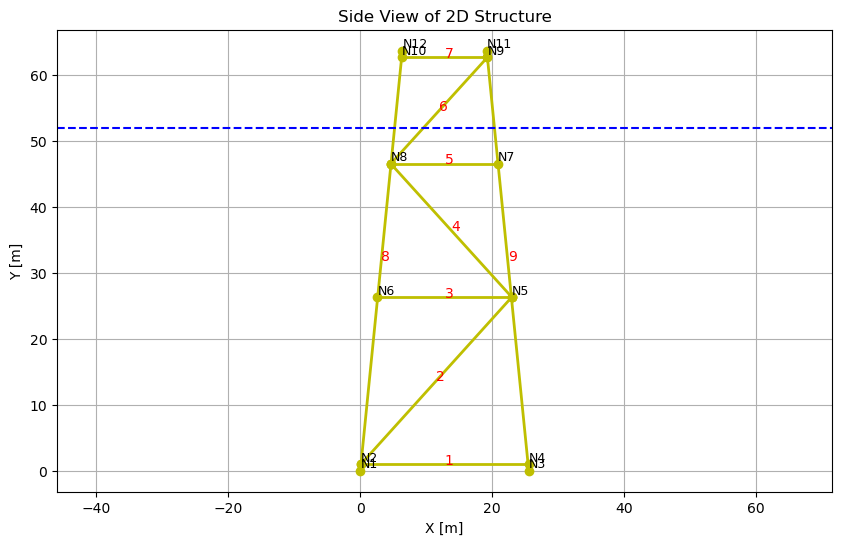

In [106]:
   
# Plot structure 
plt.figure(figsize=(10,6))
plt.title("Side View of 2D Structure")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.axis('equal')

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]
    plt.plot([x1, x2], [y1, y2], 'y-o', linewidth=2)

    # label element id
    xm, ym = (x1 + x2)/2, (y1 + y2)/2
    plt.text(xm, ym, str(elem["id"]), color='red', fontsize=10)

# label nodes
for nid, (x, y) in nodes.items():
    plt.text(x, y, f"N{nid}", color='black', fontsize=9, verticalalignment='bottom')
    
plt.axhline(52, color="blue", linestyle="dashed")
plt.grid(True)
plt.show()

In [98]:
print(nodes[1][0])

0.0


In [99]:
bay1 = {}
bay1["equalradius"] = ((nodes[6][0]+nodes[2][0])/2 + (nodes[5][0]+nodes[4][0])/2)/2

print(bay1)

{'equalradius': 12.790129911958875}
